In [1]:
!pip install ultralytics

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil
import random
import yaml
import xml.etree.ElementTree as ET
import unicodedata
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split

DATA_ROOT = Path("/content/drive/MyDrive/먼작귀/dataset/training")
OUTPUT_ROOT = Path("/content/drive/MyDrive/먼작귀/dataset/yolo_product_dataset")

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

VAL_RATIO = 0.2
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

In [ ]:
# 한글 정규화
def normalize_text(text):
    text = unicodedata.normalize("NFC", str(text))
    return (
        text
        .replace(" ", "")
        .replace("\u200b", "")
        .replace("\ufeff", "")
        .strip()
    )

In [ ]:
# 카테고리 이름만 추출
def clean_category_name(folder_name):
    name = normalize_text(folder_name)

    remove_words = [
        "[원천]", "[라벨]",
        "원천", "라벨",
        "(선정데이터)", "선정데이터",
        "(", ")", "[", "]"
    ]

    for word in remove_words:
        name = name.replace(word, "")

    return name.strip()

In [ ]:

def safe_filename(text):
    text = unicodedata.normalize("NFC", str(text))
    text = text.replace("/", "_").replace("\\", "_")
    text = text.replace(" ", "")
    text = text.replace("[", "").replace("]", "")
    text = text.replace("(", "").replace(")", "")
    return text

In [ ]:

# 원천/라벨 데이터 폴더 매칭
def get_selected_data_folders(data_root):
    source_folders = {}
    label_folders = {}

    for folder in data_root.iterdir():
        if not folder.is_dir():
            continue

        original_name = folder.name
        normalized_name = normalize_text(original_name)

        # 선정데이터가 포함되지 않은 폴더는 사용하지 않음
        if "선정데이터" not in normalized_name:
            continue

        # 과자, 면류, 기타 같은 카테고리명 추출
        category_name = clean_category_name(original_name)

        # 원천 폴더면 이미지 폴더로 저장
        if "원천" in normalized_name:
            source_folders[category_name] = folder

        # 라벨 폴더면 XML 폴더로 저장
        elif "라벨" in normalized_name:
            label_folders[category_name] = folder

    matched = []

    # 원천과 라벨이 둘 다 있는 카테고리만 사용
    for category_name in sorted(source_folders.keys()):
        if category_name in label_folders:
            matched.append({
                "category": category_name,
                "source_root": source_folders[category_name],
                "label_root": label_folders[category_name]
            })
        else:
            print(f"[경고] 라벨 폴더가 없는 카테고리: {category_name}")

    # 라벨만 있고 원천이 없는 경우도 경고 출력
    for category_name in sorted(label_folders.keys()):
        if category_name not in source_folders:
            print(f"[경고] 원천 폴더가 없는 카테고리: {category_name}")

    return matched

In [ ]:
# XML 파싱
def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    objects = []

    for obj in root.findall("object"):
        name = obj.find("name").text.strip()

        bndbox = obj.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        objects.append({
            "name": name,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return width, height, objects

In [ ]:
# VOC 좌표를 YOLO 좌표로 변환
def voc_to_yolo_bbox(bbox, img_width, img_height):
    xmin, ymin, xmax, ymax = bbox

    x_center = ((xmin + xmax) / 2) / img_width
    y_center = ((ymin + ymax) / 2) / img_height
    box_width = (xmax - xmin) / img_width
    box_height = (ymax - ymin) / img_height

    return x_center, y_center, box_width, box_height

In [ ]:

def build_product_dir_map(root_dir):
    product_map = {}

    for product_dir in root_dir.iterdir():
        if product_dir.is_dir():
            key = normalize_text(product_dir.name)
            product_map[key] = product_dir

    return product_map

In [ ]:
# XML 파일명과 같은 이름인 이미지 파일 찾기
def find_image_file(image_dir, stem):
    for ext in IMAGE_EXTENSIONS:
        candidate = image_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate

        candidate_upper = image_dir / f"{stem}{ext.upper()}"
        if candidate_upper.exists():
            return candidate_upper

    target_stem = normalize_text(stem)

    for file_path in image_dir.iterdir():
        if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS:
            if normalize_text(file_path.stem) == target_stem:
                return file_path

    return None

In [ ]:

def build_image_file_map(image_dir):
    image_map = {}

    for file_path in image_dir.iterdir():
        if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS:
            key = normalize_text(file_path.stem)
            image_map[key] = file_path

    return image_map

In [ ]:

# 이미지-XML pair 수집
def collect_pairs(matched_folders):
    pairs = []
    class_names = set()

    for item in matched_folders:
        category = item["category"]
        source_root = item["source_root"]
        label_root = item["label_root"]

        print(f"\n[{category}] 수집 중")

        # 원천 폴더 안의 상품 폴더들을 정규화된 이름으로 매핑
        source_product_map = build_product_dir_map(source_root)

        # 라벨 폴더 안의 상품 폴더 목록
        product_dirs = [p for p in label_root.iterdir() if p.is_dir()]

        for product_label_dir in tqdm(product_dirs, desc=f"{category} 상품 폴더 처리"):
            product_key = normalize_text(product_label_dir.name)

            if product_key not in source_product_map:
                print(f"[경고] 원천에 대응되는 상품 폴더 없음: {product_label_dir.name}")
                continue

            product_image_dir = source_product_map[product_key]

            # 이 상품 폴더의 이미지 파일 목록을 한 번만 읽음
            image_map = build_image_file_map(product_image_dir)

            # _meta.xml 제외
            xml_files = [
                xml_path for xml_path in product_label_dir.glob("*.xml")
                if not xml_path.stem.lower().endswith("_meta")
            ]

            for xml_path in xml_files:
                xml_key = normalize_text(xml_path.stem)

                # dictionary에서 바로 이미지 찾기
                image_path = image_map.get(xml_key)

                if image_path is None:
                    print(f"[경고] XML에 대응되는 이미지 없음: {xml_path.name}")
                    continue

                try:
                    width, height, objects = parse_xml(xml_path)
                except Exception as e:
                    print(f"[경고] XML 파싱 실패: {xml_path.name}, 에러: {e}")
                    continue

                if len(objects) == 0:
                    continue

                for obj in objects:
                    class_names.add(obj["name"])

                pairs.append({
                    "image_path": image_path,
                    "xml_path": xml_path,
                    "category": category,
                    "product_folder": unicodedata.normalize("NFC", product_label_dir.name)
                })

    return pairs, sorted(list(class_names))

In [ ]:

# YOLO txt 라벨 저장
def convert_and_save(pair, split, class_to_idx):
    image_path = pair["image_path"]
    xml_path = pair["xml_path"]

    width, height, objects = parse_xml(xml_path)

    category = safe_filename(pair["category"])
    product_folder = safe_filename(pair["product_folder"])
    image_stem = safe_filename(image_path.stem)

    # 파일명 충돌을 막기 위해 카테고리명 + 상품폴더명 + 이미지명을 합칩니다.
    new_stem = f"{category}_{product_folder}_{image_stem}"

    output_image_path = OUTPUT_ROOT / "images" / split / f"{new_stem}{image_path.suffix.lower()}"
    output_label_path = OUTPUT_ROOT / "labels" / split / f"{new_stem}.txt"

    # 원본 이미지를 YOLO 데이터셋 폴더로 복사
    shutil.copy2(image_path, output_image_path)

    yolo_lines = []

    for obj in objects:
        class_name = obj["name"]
        class_id = class_to_idx[class_name]

        x_center, y_center, box_width, box_height = voc_to_yolo_bbox(
            obj["bbox"],
            width,
            height
        )

        # 좌표가 혹시 0~1 범위를 벗어나면 보정합니다.
        x_center = min(max(x_center, 0), 1)
        y_center = min(max(y_center, 0), 1)
        box_width = min(max(box_width, 0), 1)
        box_height = min(max(box_height, 0), 1)

        # 너비나 높이가 0 이하인 비정상 박스는 제외합니다.
        if box_width <= 0 or box_height <= 0:
            continue

        yolo_lines.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} {box_width:.6f} {box_height:.6f}"
        )

    with open(output_label_path, "w", encoding="utf-8") as f:
        f.write("\n".join(yolo_lines))

In [ ]:
# 원천/라벨 폴더 매칭
matched_folders = get_selected_data_folders(DATA_ROOT)

print("매칭된 카테고리 수:", len(matched_folders))
for item in matched_folders:
    print("-", item["category"])

if len(matched_folders) == 0:
    raise ValueError("매칭된 카테고리가 없습니다. DATA_ROOT 경로 또는 폴더명을 확인하세요.")

매칭된 카테고리 수: 5
- 과자
- 기타
- 면류
- 상온
- 통조림_안주


In [ ]:
pairs, class_names = collect_pairs(matched_folders)

print("\n전체 이미지-XML pair 수:", len(pairs))
print("전체 상품 클래스 수:", len(class_names))

if len(pairs) == 0:
    raise ValueError("이미지와 XML pair를 찾지 못했습니다.")


[과자] 수집 중


과자 상품 폴더 처리: 100%|██████████| 11/11 [00:02<00:00,  3.91it/s]



[기타] 수집 중


기타 상품 폴더 처리: 100%|██████████| 14/14 [00:03<00:00,  3.72it/s]



[면류] 수집 중


...


[상온] 수집 중


상온 상품 폴더 처리: 100%|██████████| 14/14 [07:45<00:00, 33.22s/it]



[통조림_안주] 수집 중


통조림_안주 상품 폴더 처리: 100%|██████████| 14/14 [10:39<00:00, 45.71s/it]


전체 이미지-XML pair 수: 7636
전체 상품 클래스 수: 67


In [ ]:
# # collect_pairs 저장
# import pickle
# from pathlib import Path

# CACHE_PATH = Path("/content/drive/MyDrive/먼작귀/dataset/pairs_classnames_cache.pkl")

# cache_data = {
#     "pairs": pairs,
#     "class_names": class_names
# }

# with open(CACHE_PATH, "wb") as f:
#     pickle.dump(cache_data, f)

# print("저장 완료:", CACHE_PATH)
# print("pairs 수:", len(pairs))
# print("class 수:", len(class_names))

In [ ]:
import pickle

CACHE_PATH = Path("/content/drive/MyDrive/먼작귀/dataset/pairs_classnames_cache.pkl")

with open(CACHE_PATH, "rb") as f:
    cache_data = pickle.load(f)

pairs = cache_data["pairs"]
class_names = cache_data["class_names"]

print("불러오기 완료")
print("pairs 수:", len(pairs))
print("class 수:", len(class_names))

불러오기 완료
pairs 수: 7636
class 수: 67


In [ ]:
import shutil
import yaml
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm


# 상품명 클래스 → 숫자 ID
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print("전체 클래스 수:", len(class_to_idx))
print("클래스 예시 10개:")
for name in class_names[:10]:
    print(name, "->", class_to_idx[name])


# 기존 YOLO 데이터셋이 있으면 삭제 후 새로 생성
if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)

for split in ["train", "val"]:
    (OUTPUT_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)


# train / val 나누기
train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=VAL_RATIO,
    random_state=RANDOM_SEED,
    shuffle=True
)

print("\nTrain 이미지 수:", len(train_pairs))
print("Val 이미지 수:", len(val_pairs))


def convert_and_save(pair, split):
    """
    이미지 1장과 XML 1개를 YOLO 형식으로 변환해서 저장합니다.

    저장 결과:
    - images/train 또는 images/val 안에 이미지 복사
    - labels/train 또는 labels/val 안에 YOLO txt 생성

    YOLO txt 형식:
    class_id x_center y_center width height
    """
    image_path = pair["image_path"]
    xml_path = pair["xml_path"]

    width, height, objects = parse_xml(xml_path)

    category = safe_filename(pair["category"])
    product_folder = safe_filename(pair["product_folder"])
    image_stem = safe_filename(image_path.stem)

    new_stem = f"{category}_{product_folder}_{image_stem}"

    output_image_path = OUTPUT_ROOT / "images" / split / f"{new_stem}{image_path.suffix.lower()}"
    output_label_path = OUTPUT_ROOT / "labels" / split / f"{new_stem}.txt"

    shutil.copy2(image_path, output_image_path)

    yolo_lines = []

    for obj in objects:
        class_name = obj["name"]
        class_id = class_to_idx[class_name]

        x_center, y_center, box_width, box_height = voc_to_yolo_bbox(
            obj["bbox"],
            width,
            height
        )

        x_center = min(max(x_center, 0), 1)
        y_center = min(max(y_center, 0), 1)
        box_width = min(max(box_width, 0), 1)
        box_height = min(max(box_height, 0), 1)

        if box_width <= 0 or box_height <= 0:
            continue

        yolo_lines.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} {box_width:.6f} {box_height:.6f}"
        )

    with open(output_label_path, "w", encoding="utf-8") as f:
        f.write("\n".join(yolo_lines))


for pair in tqdm(train_pairs, desc="Convert train"):
    convert_and_save(pair, "train")

for pair in tqdm(val_pairs, desc="Convert val"):
    convert_and_save(pair, "val")


# YOLO 학습용 data.yaml 생성
data_yaml = {
    "path": str(OUTPUT_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "names": {idx: name for name, idx in class_to_idx.items()}
}

with open(OUTPUT_ROOT / "data.yaml", "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, allow_unicode=True, sort_keys=False)

print("\nYOLO 데이터셋 생성 완료")
print("저장 위치:", OUTPUT_ROOT)
print("data.yaml:", OUTPUT_ROOT / "data.yaml")

전체 클래스 수: 67
클래스 예시 10개:
(주)국모싸이언스)메디안칼슘치약75G -> 0
CJ다담떡볶이양념 -> 1
CJ렛츠웰맛밤80G -> 2
CJ맥스봉체다치즈어랏400G -> 3
CJ비비고스팸부대찌개460G -> 4
CJ스팸200G -> 5
CJ햇반컵반설렁탕밥253g -> 6
골드)황도슬라이스 -> 7
길림양행)구운아몬드 -> 8
깨끗한나라여행용티슈핑크50매 -> 9

Train 이미지 수: 6108
Val 이미지 수: 1528


Convert val: 100%|██████████| 1528/1528 [13:13<00:00,  1.93it/s]


YOLO 데이터셋 생성 완료
저장 위치: /content/drive/MyDrive/먼작귀/dataset/yolo_product_dataset
data.yaml: /content/drive/MyDrive/먼작귀/dataset/yolo_product_dataset/data.yaml


In [ ]:
from pathlib import Path

label_dir = Path("/content/drive/MyDrive/먼작귀/dataset/yolo_product_dataset/labels/train")
label_files = list(label_dir.glob("*.txt"))

print("라벨 파일 수:", len(label_files))

sample_label = label_files[0]
print("샘플 라벨:", sample_label)

with open(sample_label, "r", encoding="utf-8") as f:
    print(f.read())

라벨 파일 수: 6108
샘플 라벨: /content/drive/MyDrive/먼작귀/dataset/yolo_product_dataset/labels/train/상온_10240_CJ햇반컵반설렁탕밥253g_10240_00_s_23.txt
6 0.493809 0.489625 0.915328 0.692102


In [ ]:
# yolo 데이터셋을 로컬로 복사
!cp -r "/content/drive/MyDrive/먼작귀/dataset/yolo_product_dataset" "/content/yolo_product_dataset"
!ls "/content/yolo_product_dataset"
!ls "/content/yolo_product_dataset/images/train" | head
!ls "/content/yolo_product_dataset/labels/train" | head

^C
data.yaml  images
과자_10091_꼬깔콘고소한맛72G_10091_0_m_10.jpg
과자_10091_꼬깔콘고소한맛72G_10091_0_m_12.jpg
과자_10091_꼬깔콘고소한맛72G_10091_0_m_14.jpg
과자_10091_꼬깔콘고소한맛72G_10091_0_m_15.jpg
과자_10091_꼬깔콘고소한맛72G_10091_0_m_16.jpg
과자_10091_꼬깔콘고소한맛72G_10091_0_m_1.jpg
과자_10091_꼬깔콘고소한맛72G_10091_0_m_20.jpg
과자_10091_꼬깔콘고소한맛72G_10091_0_m_21.jpg
과자_10091_꼬깔콘고소한맛72G_10091_0_m_23.jpg
과자_10091_꼬깔콘고소한맛72G_10091_0_m_2.jpg
ls: cannot access '/content/yolo_product_dataset/labels/train': No such file or directory


In [ ]:
# 로컬용 data.yaml 새로 만들기
import yaml
from pathlib import Path

LOCAL_YOLO_ROOT = Path("/content/yolo_product_dataset")

data_yaml_path = LOCAL_YOLO_ROOT / "data.yaml"

with open(data_yaml_path, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

data_yaml["path"] = str(LOCAL_YOLO_ROOT)

with open(data_yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, allow_unicode=True, sort_keys=False)

print(data_yaml)

In [ ]:
# YOLO 학습
from ultralytics import YOLO
import torch

print("CUDA 사용 가능:", torch.cuda.is_available())

model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/먼작귀/dataset/yolo_product_dataset/data.yaml",
    epochs=50,
    patience=10,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    project="/content/drive/MyDrive/먼작귀/runs/product_detection",
    name="yolov8n_product",
    save=True,
    save_period=-1
)

CUDA 사용 가능: True
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/먼작귀/dataset/yolo_product_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_product-3, nbs=64, nms=False, opset=None, opt

In [ ]:
!ls "/content/drive/MyDrive/먼작귀/runs/product_detection/yolov8n_product-3/weights"

best.pt  last.pt


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/먼작귀/runs/product_detection/yolov8n_product-3/weights/last.pt")

model.train(resume=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/먼작귀/dataset/yolo_product_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7942ca072ff0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,   

In [ ]:
from ultralytics import YOLO
from pathlib import Path
from IPython.display import Image, display
import random

# 1. 학습된 best 모델 경로
model_path = "/content/drive/MyDrive/먼작귀/runs/product_detection/yolov8n_product-3/weights/best.pt"

# 2. val 이미지 폴더 경로
val_dir = Path("/content/drive/MyDrive/먼작귀/dataset/yolo_product_dataset/images/val")

# 3. val 이미지 중 랜덤으로 5장 선택
all_image_files = [
    p for p in val_dir.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
]

image_files = random.sample(all_image_files, 5)

print("랜덤 선택된 이미지:")
for p in image_files:
    print(p.name)

# 4. 모델 불러오기
model = YOLO(model_path)

# 5. 5장만 예측
results = model.predict(
    source=[str(p) for p in image_files],
    imgsz=640,
    conf=0.25,
    save=True,
    project="/content/runs/detect",
    name="val_5_predict_random",
    exist_ok=True
)

print("예측 완료")

랜덤 선택된 이미지:
과자_90089_롯데칸쵸컵88G_90089_0_s_17.jpg
과자_10091_꼬깔콘고소한맛72G_10091_60_s_2.jpg
통조림_안주_50079_CJ렛츠웰맛밤80G_50079_60_m_24.jpg
기타_25165_주국모싸이언스메디안칼슘치약75G_25165_30_s_9.jpg
기타_55337_에프킬라무향수성_55337_30_m_1.jpg

0: 640x640 1 롯데칸쵸컵88G, 5.7ms
1: 640x640 1 꼬깔콘고소한맛72G, 5.7ms
2: 640x640 3 CJ렛츠웰맛밤80Gs, 5.7ms
3: 640x640 1 (주)국모싸이언스)메디안칼슘치약75G, 5.7ms
4: 640x640 2 에프킬라무향수성s, 5.7ms
Speed: 3.5ms preprocess, 5.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/val_5_predict_random
예측 완료


결과 이미지 수: 15


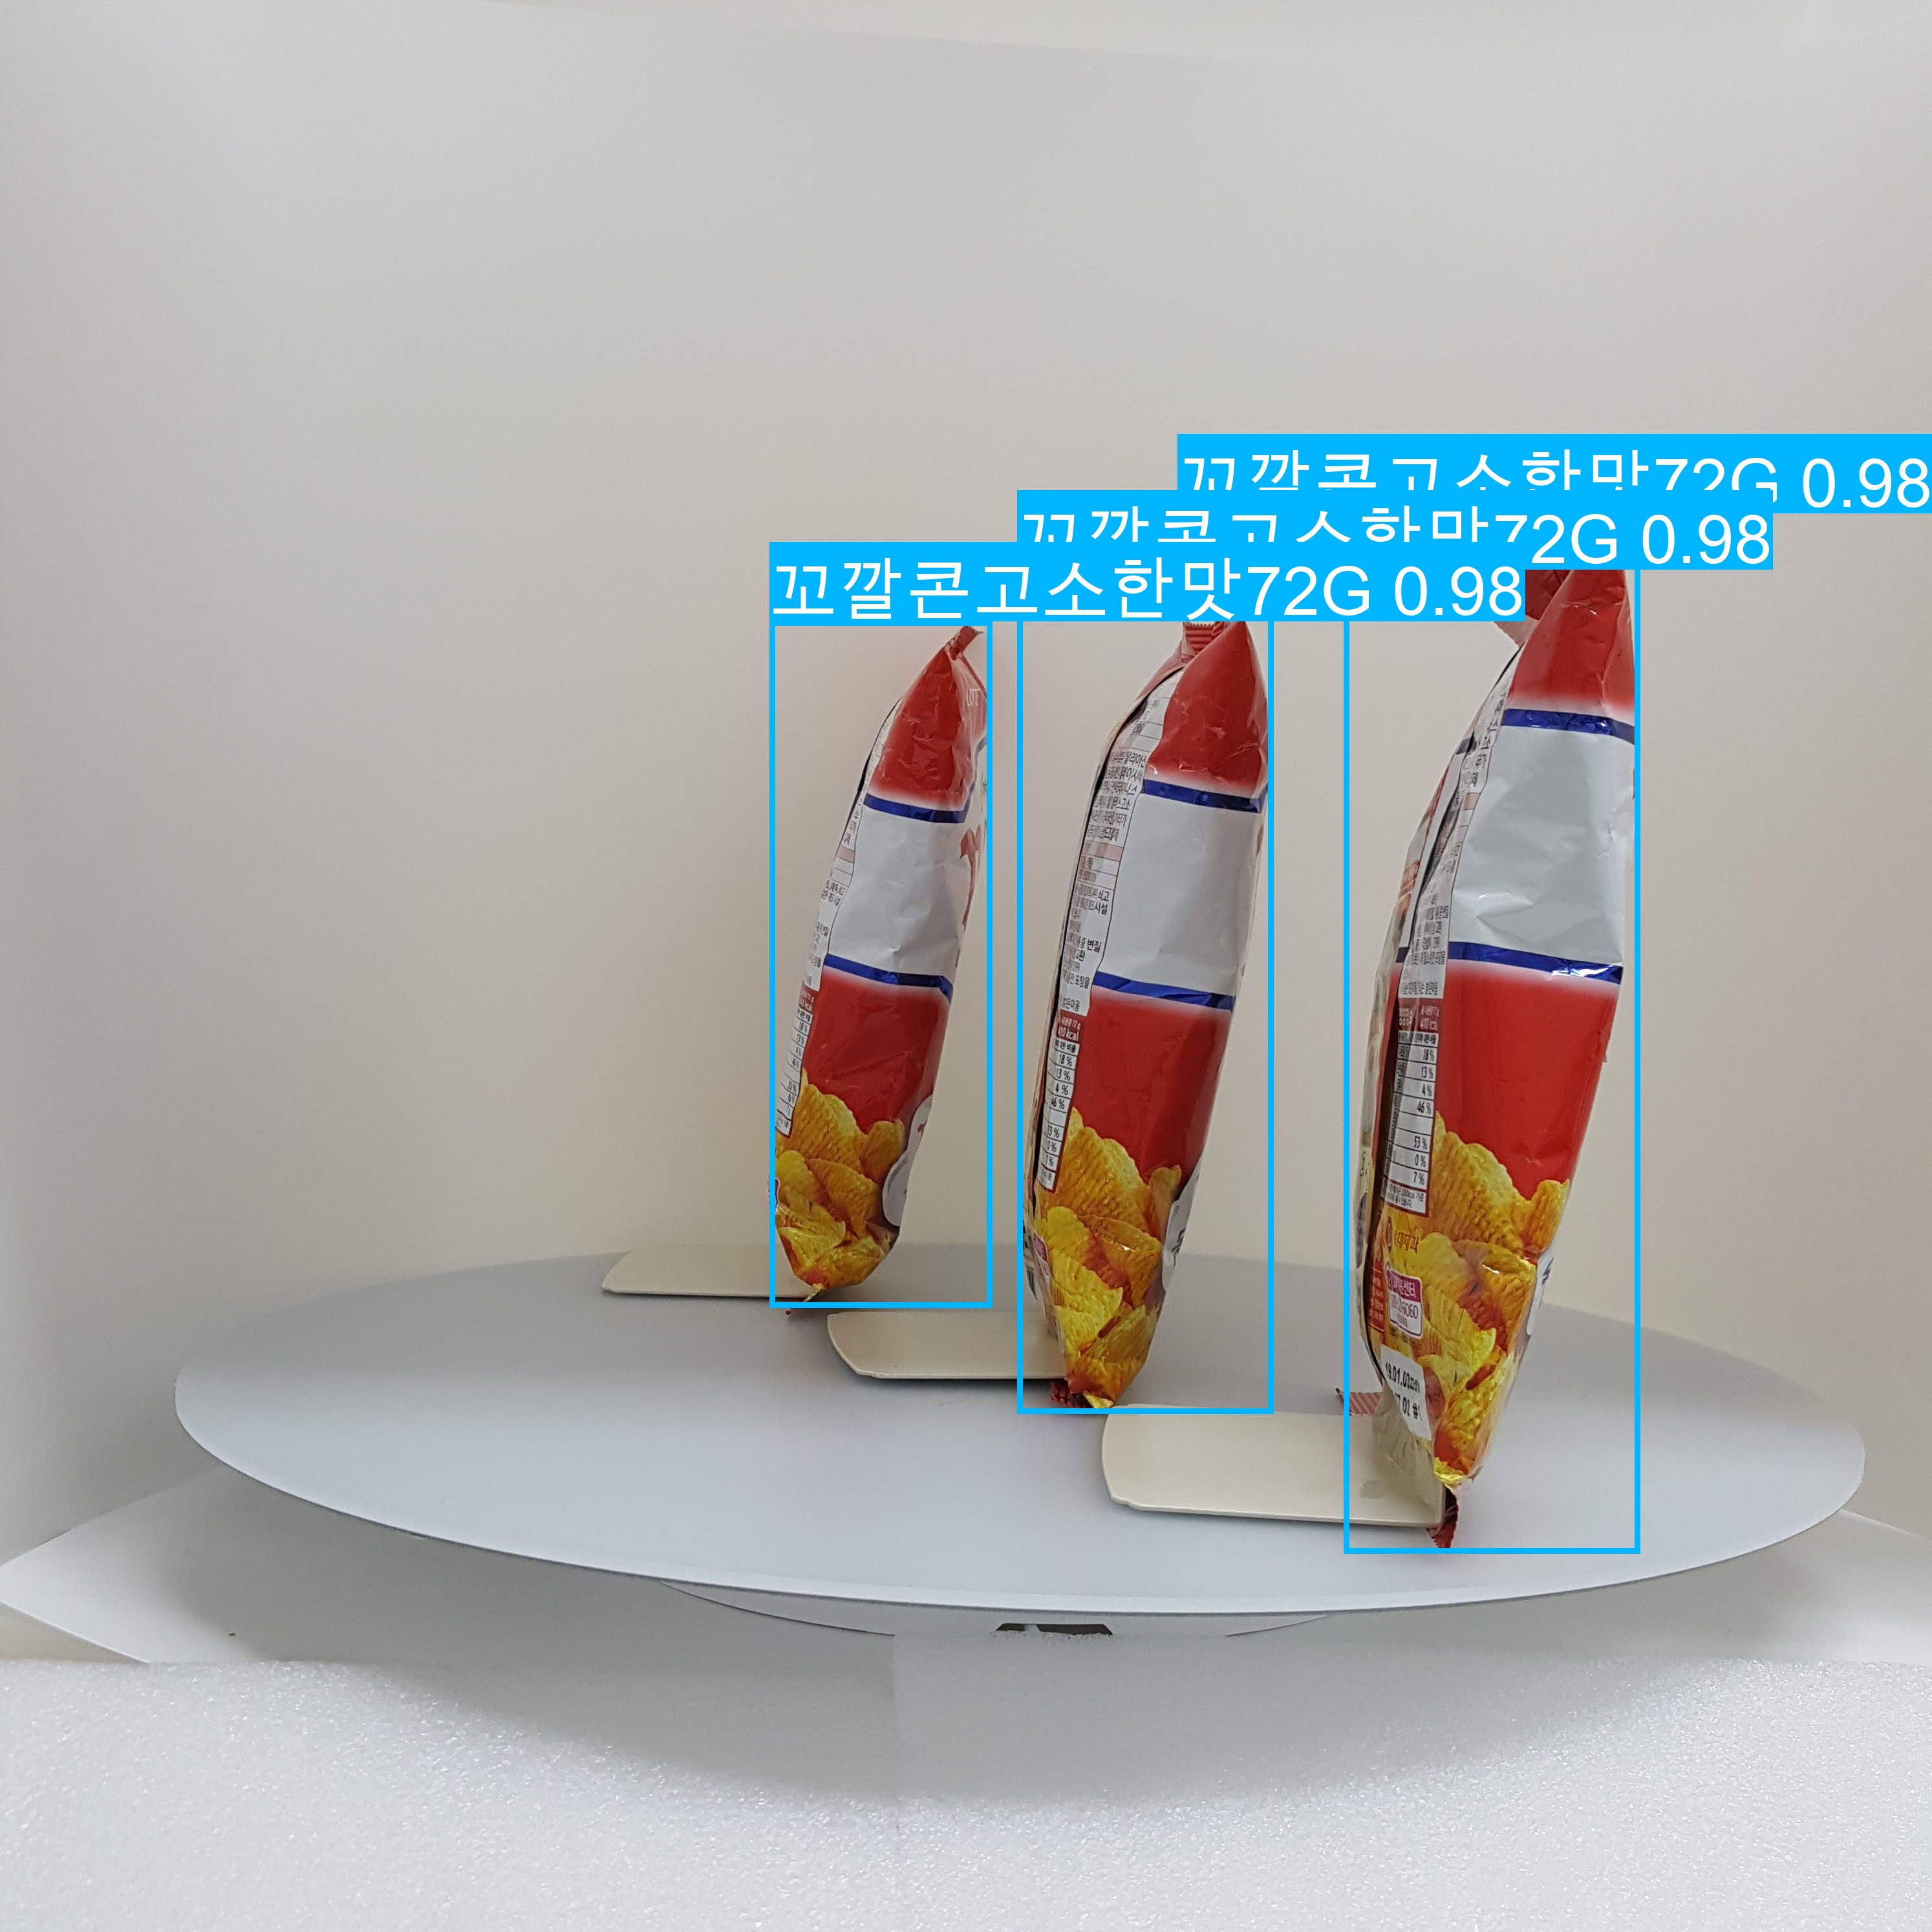

In [ ]:
import os
from IPython.display import Image, display

result_dir = "/content/runs/detect/predict"

image_files = [
    f for f in os.listdir(result_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("결과 이미지 수:", len(image_files))

display(Image(filename=os.path.join(result_dir, image_files[0])))

Saving image (13).png to image (13) (2).png
업로드한 이미지: image (13) (2).png

image 1/1 /content/image (13) (2).png: 512x640 3 농심순한너구리120Gs, 3 팔도더왕뚜껑컵순한맛101Gs, 54.9ms
Speed: 4.6ms preprocess, 54.9ms inference, 18.0ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /content/runs/detect/single_image_predict
예측 완료


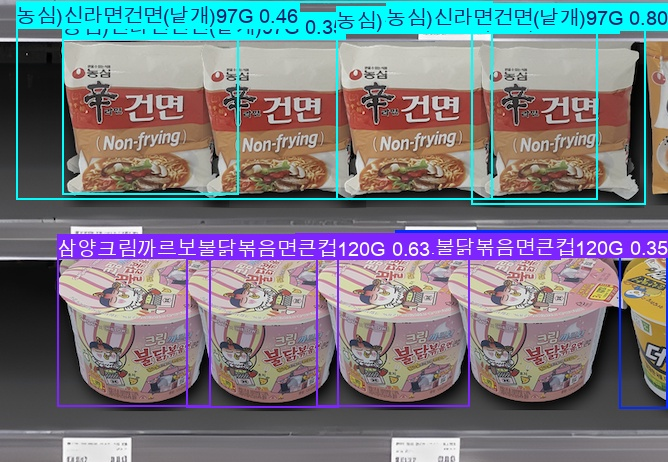

In [3]:
from google.colab import files
from ultralytics import YOLO
from IPython.display import Image, display
from pathlib import Path

# 1. 이미지 1장 업로드
uploaded = files.upload()

# 업로드한 첫 번째 파일명 가져오기
image_path = list(uploaded.keys())[0]

print("업로드한 이미지:", image_path)

# 2. 학습된 모델 불러오기
model_path = "/content/drive/MyDrive/먼작귀/runs/product_detection/yolov8n_product-3/weights/best.pt"
model = YOLO(model_path)

# 3. 업로드한 이미지 1장 예측
results = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    save=True,
    project="/content/runs/detect",
    name="single_image_predict",
    exist_ok=True
)

print("예측 완료")

# 4. 예측 결과 이미지 바로 보기
result_dir = Path("/content/runs/detect/single_image_predict")

result_images = sorted([
    p for p in result_dir.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
])

display(Image(filename=str(result_images[0]), width=700))